In [443]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter

In [393]:
OUTPUTS_DIR = Path("/Users/hyeon/SeSAC_Project/PoC/run/test7/outputs")
hpe = OUTPUTS_DIR / "pose_predictions.json"

with hpe.open(mode= "r", encoding= 'utf-8') as file:
    pose_data = json.load(file)

In [394]:
pose_data

{'frames': [{'image_path': 'run/test7/inputs/00000147.png',
   'people': [{'track_id': 0,
     'bbox': [1566.204345703125,
      255.21926879882812,
      1885.7896728515625,
      948.8587646484375],
     'bbox_score': 1.0,
     'keypoints': [[1606.326178656684, 331.08605194091797],
      [1618.744856092665, 318.66737508773804],
      [1607.4551493326824, 316.4094338417053],
      [1661.645741780599, 329.9570813179016],
      [1667.2905951605903, 320.92531633377075],
      [1684.2251553005642, 387.53458309173584],
      [1640.1952989366318, 406.7270836830139],
      [1748.5764838324653, 475.5942916870117],
      [1661.645741780599, 511.72135162353516],
      [1677.4513312445747, 554.6222352981567],
      [1616.4869147406685, 564.782970905304],
      [1698.9017740885415, 604.2969427108765],
      [1641.3242696126301, 608.8128252029419],
      [1703.4176567925347, 769.1266536712646],
      [1630.0345628526475, 765.7397418022156],
      [1846.7969326443144, 796.2219486236572],
      [167

In [395]:
pose_data["frames"].__len__()

78

In [396]:
Halpe_26_keypoints = {
    0: "nose",
    1: "left_eye",
    2: "right_eye",
    3: "left_ear",
    4: "right_ear",
    5: "left_shoulder",
    6: "right_shoulder",
    7: "left_elbow",
    8: "right_elbow",
    9: "left_wrist",
    10: "right_wrist",
    11: "left_hip",
    12: "right_hip",
    13: "left_knee",
    14: "right_knee",
    15: "left_ankle",
    16: "right_ankle",
    17: "head",
    18: "neck",
    19: "hip_center",
    20: "left_big_toe",
    21: "right_big_toe",
    22: "left_small_toe",
    23: "right_small_toe",
    24: "left_heel",
    25: "right_heel",
}

In [397]:
def hpe2pd(pose_data: dict) -> pd.DataFrame:
    """
    hpe json 데이터를 pandas DataFrame으로 변경
    Returns:
        pd.DataFrame has bbox(4), keypoints(26)
    """
    rows = []
    
    for frame in pose_data["frames"]:
        row = {}

        if frame['people'] == []:
            # 사람이 포착되지 않음.
            continue
        bbox = frame['people'][0]["bbox"]
        row["bbox_left"], row["bbox_up"], row["bbox_right"], row["bbox_down"] = bbox

        for i, xy in enumerate(frame['people'][0]['keypoints']):
            row[f"{Halpe_26_keypoints[i]}_x"] = xy[0]
            row[f"{Halpe_26_keypoints[i]}_y"] = xy[1]
        rows.append(row)
    
    return pd.DataFrame.from_records(rows)

In [398]:
df = hpe2pd(pose_data)
df

,bbox_left,bbox_up,bbox_right,bbox_down,nose_x,nose_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,...,right_big_toe_x,right_big_toe_y,left_small_toe_x,left_small_toe_y,right_small_toe_x,right_small_toe_y,left_heel_x,left_heel_y,right_heel_x,right_heel_y
0,1566.204346,255.219269,1885.789673,948.858765,1606.326179,331.086052,1618.744856,318.667375,1607.455149,316.409434,...,1618.744856,929.440482,1871.634288,865.089157,1621.002797,926.053570,1869.376346,780.416360,1710.191481,919.279747
1,1558.756836,270.716461,1868.142700,948.910034,1585.405339,334.959379,1597.547477,322.817241,1585.405339,321.713411,...,1618.520262,927.716484,1842.597906,876.940270,1621.831754,923.301161,1838.182583,785.322319,1709.034384,918.885838
2,1544.564941,272.196381,1829.895386,951.968079,1565.526299,334.375991,1578.803091,322.205598,1566.632698,321.099199,...,1617.527067,928.512414,1808.934150,877.618046,1624.165463,924.086816,1807.827751,793.531699,1702.719815,921.874018
3,1412.392090,275.420197,1802.677368,952.883484,1547.991997,332.978130,1561.223701,320.849068,1550.197281,318.643784,...,1616.355804,929.507484,1766.315125,889.812370,1625.176941,923.994274,1776.238903,817.037994,1697.951317,921.788990
4,1409.595337,273.017883,1764.418335,950.563110,1529.662517,330.582797,1541.793046,318.452267,1531.868068,317.349492,...,1617.884546,929.389847,1722.648205,890.792707,1624.501198,923.875970,1742.498162,820.215081,1692.873271,921.670419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,109.225418,287.043213,401.628021,947.226929,180.210483,340.984015,190.955661,331.313355,185.583072,328.089802,...,368.251094,873.944808,174.837894,929.819729,380.070790,862.125113,255.426727,920.149070,363.953023,775.089177
74,94.365807,288.682800,313.994934,942.968628,160.518724,344.271502,170.102988,333.622318,165.843315,331.492482,...,330.905653,878.860518,175.427580,928.911681,339.424999,861.821825,247.842025,918.262498,330.905653,784.082784
75,69.426704,288.547668,290.821320,943.534790,140.679797,343.129964,151.340395,332.469367,144.944036,330.337247,...,283.531804,882.556197,176.925829,930.528886,293.126342,867.631360,253.682131,916.670109,301.654819,793.007178
76,48.431145,286.350952,289.958832,950.820190,122.690795,339.560403,131.342739,327.663981,128.098260,326.582488,...,243.818006,884.632825,178.928429,931.137020,248.143978,873.817896,249.225471,915.996119,273.018316,807.846829


### 결측치 검사

In [399]:
df.isna().sum().sum()

np.int64(0)

In [400]:
df.describe()

,bbox_left,bbox_up,bbox_right,bbox_down,nose_x,nose_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,...,right_big_toe_x,right_big_toe_y,left_small_toe_x,left_small_toe_y,right_small_toe_x,right_small_toe_y,left_heel_x,left_heel_y,right_heel_x,right_heel_y
count,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,...,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000
mean,794.041479,255.460980,1106.202531,943.912713,859.564296,316.755034,871.608916,306.015674,862.102652,303.520270,...,983.032621,893.541733,938.638841,903.475535,986.327951,886.041980,986.815841,870.804137,1022.514586,838.923980
std,456.375395,22.201027,456.797278,8.939591,443.644595,18.401305,444.547986,18.366512,442.252293,18.746974,...,451.847127,27.963077,495.405062,24.328869,449.891096,28.785180,484.711421,55.724376,458.759617,61.458471
min,31.423119,212.044144,276.592926,916.254089,105.944621,284.128377,115.775772,273.034584,110.314022,269.261985,...,214.087282,848.954616,172.558777,852.126972,211.902582,839.869833,242.488385,758.269868,241.396035,747.960973
25%,424.054436,237.964508,738.812958,939.641830,482.745921,303.127434,493.742906,292.751433,484.720109,289.180094,...,661.305875,869.486750,474.560445,887.310154,668.024728,865.393766,545.333463,820.970403,707.189812,780.651526
50%,770.535858,255.843491,1157.608704,945.419250,864.015454,318.423943,875.258261,307.897076,867.952505,305.249515,...,777.429295,884.940003,1129.918173,908.582803,783.050698,874.766615,1135.527166,897.619116,848.814912,842.170176
75%,1174.024719,273.228867,1524.671265,950.308640,1238.439519,333.228234,1251.537137,322.250250,1239.893623,319.042143,...,1498.674718,925.595764,1181.075185,925.361859,1496.346016,918.482622,1258.512562,916.688638,1498.390307,902.457508
max,1566.204346,297.882141,1885.789673,961.719971,1606.326179,344.531655,1618.744856,333.836707,1607.455149,334.811142,...,1623.920303,936.488731,1871.634288,931.228408,1625.874831,927.390929,1869.376346,925.723403,1710.191481,921.874018


In [401]:
left_ankle_x = df["left_ankle_x"]
type(left_ankle_x)

pandas.Series

In [402]:
details = OUTPUTS_DIR / "details.json"
with details.open(mode= "r", encoding= 'utf-8') as file:
    details_data = json.load(file)

In [403]:
df

,bbox_left,bbox_up,bbox_right,bbox_down,nose_x,nose_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,...,right_big_toe_x,right_big_toe_y,left_small_toe_x,left_small_toe_y,right_small_toe_x,right_small_toe_y,left_heel_x,left_heel_y,right_heel_x,right_heel_y
0,1566.204346,255.219269,1885.789673,948.858765,1606.326179,331.086052,1618.744856,318.667375,1607.455149,316.409434,...,1618.744856,929.440482,1871.634288,865.089157,1621.002797,926.053570,1869.376346,780.416360,1710.191481,919.279747
1,1558.756836,270.716461,1868.142700,948.910034,1585.405339,334.959379,1597.547477,322.817241,1585.405339,321.713411,...,1618.520262,927.716484,1842.597906,876.940270,1621.831754,923.301161,1838.182583,785.322319,1709.034384,918.885838
2,1544.564941,272.196381,1829.895386,951.968079,1565.526299,334.375991,1578.803091,322.205598,1566.632698,321.099199,...,1617.527067,928.512414,1808.934150,877.618046,1624.165463,924.086816,1807.827751,793.531699,1702.719815,921.874018
3,1412.392090,275.420197,1802.677368,952.883484,1547.991997,332.978130,1561.223701,320.849068,1550.197281,318.643784,...,1616.355804,929.507484,1766.315125,889.812370,1625.176941,923.994274,1776.238903,817.037994,1697.951317,921.788990
4,1409.595337,273.017883,1764.418335,950.563110,1529.662517,330.582797,1541.793046,318.452267,1531.868068,317.349492,...,1617.884546,929.389847,1722.648205,890.792707,1624.501198,923.875970,1742.498162,820.215081,1692.873271,921.670419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,109.225418,287.043213,401.628021,947.226929,180.210483,340.984015,190.955661,331.313355,185.583072,328.089802,...,368.251094,873.944808,174.837894,929.819729,380.070790,862.125113,255.426727,920.149070,363.953023,775.089177
74,94.365807,288.682800,313.994934,942.968628,160.518724,344.271502,170.102988,333.622318,165.843315,331.492482,...,330.905653,878.860518,175.427580,928.911681,339.424999,861.821825,247.842025,918.262498,330.905653,784.082784
75,69.426704,288.547668,290.821320,943.534790,140.679797,343.129964,151.340395,332.469367,144.944036,330.337247,...,283.531804,882.556197,176.925829,930.528886,293.126342,867.631360,253.682131,916.670109,301.654819,793.007178
76,48.431145,286.350952,289.958832,950.820190,122.690795,339.560403,131.342739,327.663981,128.098260,326.582488,...,243.818006,884.632825,178.928429,931.137020,248.143978,873.817896,249.225471,915.996119,273.018316,807.846829


In [404]:
df["bbox_down"].diff()

0           NaN
1      0.051270
2      3.058044
3      0.915405
4     -2.320374
        ...    
73   -14.493042
74    -4.258301
75     0.566162
76     7.285400
77    -0.030579
Name: bbox_down, Length: 78, dtype: float64

In [405]:
def vel_acc(df: pd.DataFrame, keypoints: list[str] = None,fps: float = 60.0, one_arrow: str = None):
    """
    정해진 형식의 df에서 구하고자 하는 키포인트의 속력(vel)과 가속력(acc)를 구한다.
    Returns:
        pd.DataFrame
    """
    if fps <= 0:
        raise ValueError("fps는 0보다 커야 합니다.")
    
    if keypoints is None:
        keypoints = list(Halpe_26_keypoints.values())
    if type(keypoints) == str:
        keypoints = list(keypoints)

    dt = 1 / fps

    res = pd.DataFrame()

    for key in keypoints:
        vx = df[f"{key}_x"].diff() / dt
        vy = df[f"{key}_y"].diff() / dt
        ax = vx.diff() / dt
        ay = vy.diff() / dt
        
        if one_arrow == 'x':
            res[f"{key}_x_vel"] = vx.abs()
            res[f"{key}_x_acc"] = ax.abs()
        if one_arrow == 'y':
            res[f"{key}_y_vel"] = vy.abs()
            res[f"{key}_y_acc"] = ay.abs()
        else:
            res[f"{key}_vel"] = np.hypot(vx, vy)
            res[f"{key}_acc"] = np.hypot(ax, ay)

    return res.iloc[2:]

In [406]:
vel_acc_df = vel_acc(df, fps=25)
vel_acc_df

,nose_vel,nose_acc,left_eye_vel,left_eye_acc,right_eye_vel,right_eye_acc,left_ear_vel,left_ear_acc,right_ear_vel,right_ear_acc,...,right_big_toe_vel,right_big_toe_acc,left_small_toe_vel,left_small_toe_acc,right_small_toe_vel,right_small_toe_acc,left_heel_vel,left_heel_acc,right_heel_vel,right_heel_acc
2,497.189956,2860.538888,468.859069,3347.640488,469.567144,4228.105254,475.874043,1638.051498,693.102768,10173.818827,...,31.819203,1646.585044,841.764455,7558.523706,61.560200,2402.975079,786.133637,2130.176826,174.647854,3854.686449
3,439.748342,1551.355019,440.791267,864.236339,415.445551,1859.587016,527.018665,3600.868128,1160.943837,12286.959611,...,38.422183,166.964727,1108.231391,9117.885906,25.392560,992.063573,984.378365,9591.630719,119.231408,2150.121424
4,462.133265,797.275765,489.448045,1327.201524,459.371338,1388.382289,506.145110,2868.103334,407.421787,18946.434190,...,38.331527,1825.186627,1091.948053,7039.275871,17.150512,1054.635711,847.249774,12776.739375,126.985757,194.599982
5,503.091463,1520.022308,507.899321,2058.193189,530.448497,2541.522554,463.439515,1184.251485,1047.848815,16012.139894,...,90.024937,1303.297149,1324.560510,7307.710974,39.023226,1338.748306,836.212380,1153.852881,407.073531,13204.292679
6,495.296907,2137.459341,483.651116,1000.816981,574.786456,2046.409023,492.236000,819.688934,807.922298,6205.548329,...,107.701488,4644.105167,917.729765,16584.146522,197.047149,5900.210390,1484.544836,29478.660629,199.844117,9597.607833
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,453.483839,3956.633930,409.550454,5086.828648,406.816906,4005.889463,422.008050,3939.650577,328.546135,10453.466555,...,1006.687906,1302.302340,66.982971,3723.102646,938.781945,1290.616503,166.007425,3830.820589,644.124440,2331.632905
74,499.107295,1980.219826,524.502887,2937.129245,500.772037,2380.989665,583.397451,5526.517314,561.142049,7092.061695,...,941.689380,1824.974091,27.067983,1101.279059,1016.173056,5208.658575,195.395222,8978.789082,856.232181,5774.814136
75,496.793530,2769.668252,469.949604,2527.449514,523.279571,2939.432285,498.066941,2152.119670,470.773475,2740.811391,...,1187.944546,6313.967330,55.114087,1677.328941,1166.543075,5203.721542,151.332708,8392.519756,764.548902,2373.230163
76,458.493441,1907.787870,514.172873,2409.750276,431.478858,3009.646387,525.353566,1023.870114,466.976284,1593.294061,...,994.201352,4893.303167,52.322514,705.057714,1135.144890,855.761247,112.683412,6461.026567,806.328327,3716.920205


In [407]:
vel_acc_df["left_big_toe_acc"].name

'left_big_toe_acc'

In [408]:
def visualize_time(_df: pd.DataFrame, fps: float) -> None:
    if type(_df) == pd.Series:
        _df = _df.to_frame()
    time = (_df.index.to_numpy() - 2) / fps

    fig, axes = plt.subplots(figsize=(12, 6))
    for col in _df.columns:
        axes.plot(time, _df[col], label=col, linewidth=1.5)
    axes.set_title("Time Series Analysis")
    axes.set_xlabel("Time (s)")
    axes.set_ylabel("pixel")
    axes.legend()
    axes.grid(alpha=0.3)

    fig.tight_layout()
    plt.show()


In [409]:
df["right_instep_x"] = (df["right_big_toe_x"] + df["right_ankle_x"]) / 2
df["right_instep_y"] = (df["right_big_toe_y"] + df["right_ankle_y"]) / 2

In [410]:
df_test = vel_acc(df, ["right_instep"], 50, one_arrow='y')["right_instep_y_acc"]

In [411]:
df_test2 = vel_acc(df, ["left_heel"], 50, one_arrow='y')["left_heel_y_vel"]


In [412]:
df_test2.loc[13] = 2000

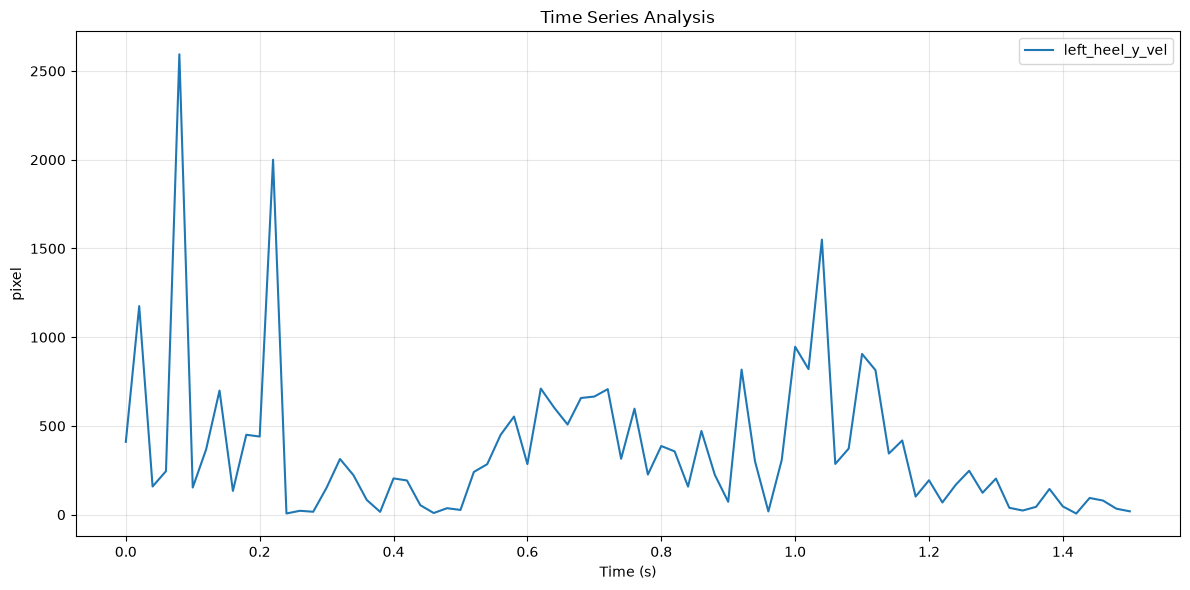

In [413]:
visualize_time(df_test2, 50)

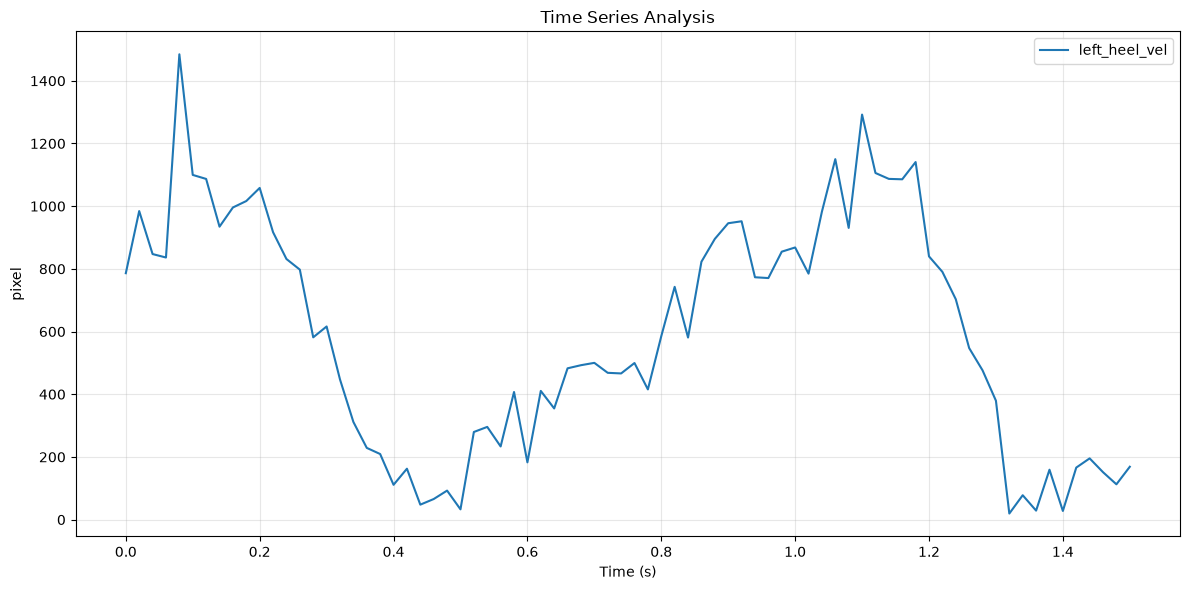

In [414]:
visualize_time(vel_acc_df["left_heel_vel"], 50)

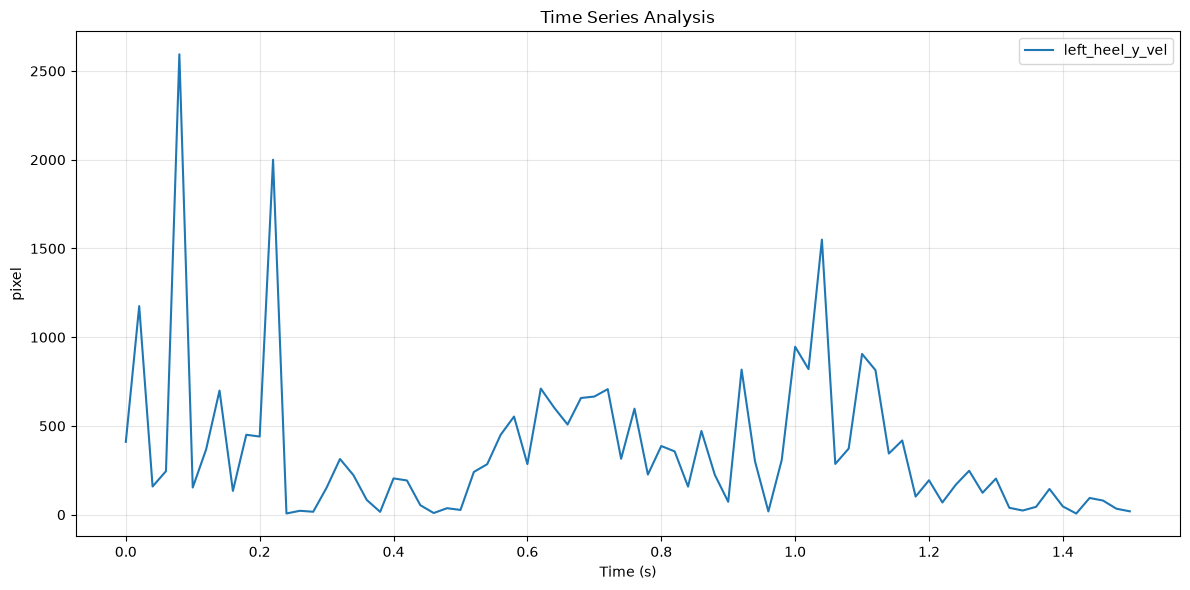

In [415]:
visualize_time(df_test2, 50)

In [416]:
'_'.join("left_heel_x".split('_')[:-1])

'left_heel'

In [417]:
# fig, ax = plt.subplots(figsize=(12, 8))
# ax.plot(df["left_heel_x"], 1080 - df["left_heel_y"])
# fig.tight_layout()
# fig.show()
def visualize_xy(_df: pd.DataFrame, height: int) -> None:
    if type(_df) == pd.Series:
        raise RuntimeError("x, y가 주어져야 합니다.")
    columns = set('_'.join(col.split('_')[:-1]) for col in _df.columns)

    fig, axes = plt.subplots(figsize=(12, 6))
    for col in columns:
        axes.plot(_df[f"{col}_x"], height - _df[f"{col}_y"], label=col, linewidth=1.5)
    axes.set_title("Trace Analysis")
    axes.set_xlabel("x")
    axes.set_ylabel("y")
    axes.legend()
    axes.grid(alpha=0.3)

    fig.tight_layout()
    plt.show()


In [418]:
def gct(df, side: str):
    """
    {side}의 heel이 지면에 접촉하고 big_toe가 지면에서 떼어지는 순간까지의 인덱스 출력
    """
    heel = f"{side}_heel"
    start = int(df[f"{heel}_y"].argmax())

    toe = f"{side}_big_toe"
    min_value = df[f"{toe}_y"].max()

    inside = df[f"{toe}_y"].between(min_value - 5, min_value)
    end = df.index[~inside & inside.shift(1, fill_value=False)].to_list()[0]
    return start - 1, end - 1




In [419]:
gct(df, "left")

(20, 6)

In [420]:
gct(df, "right")

(1, 10)

In [421]:
heel = "left_heel"
max_value = df[f"{heel}_y"].argmax()

In [422]:
max_value - 1

np.int64(20)

In [423]:
df[f"{heel}_y"]

0     780.416360
1     785.322319
2     793.531699
3     817.037994
4     820.215081
         ...    
73    920.149070
74    918.262498
75    916.670109
76    915.996119
77    915.615939
Name: left_heel_y, Length: 78, dtype: float64

In [424]:
[df[f"{heel}_y"] > max_value - 10]

[0     True
 1     True
 2     True
 3     True
 4     True
       ... 
 73    True
 74    True
 75    True
 76    True
 77    True
 Name: left_heel_y, Length: 78, dtype: bool]

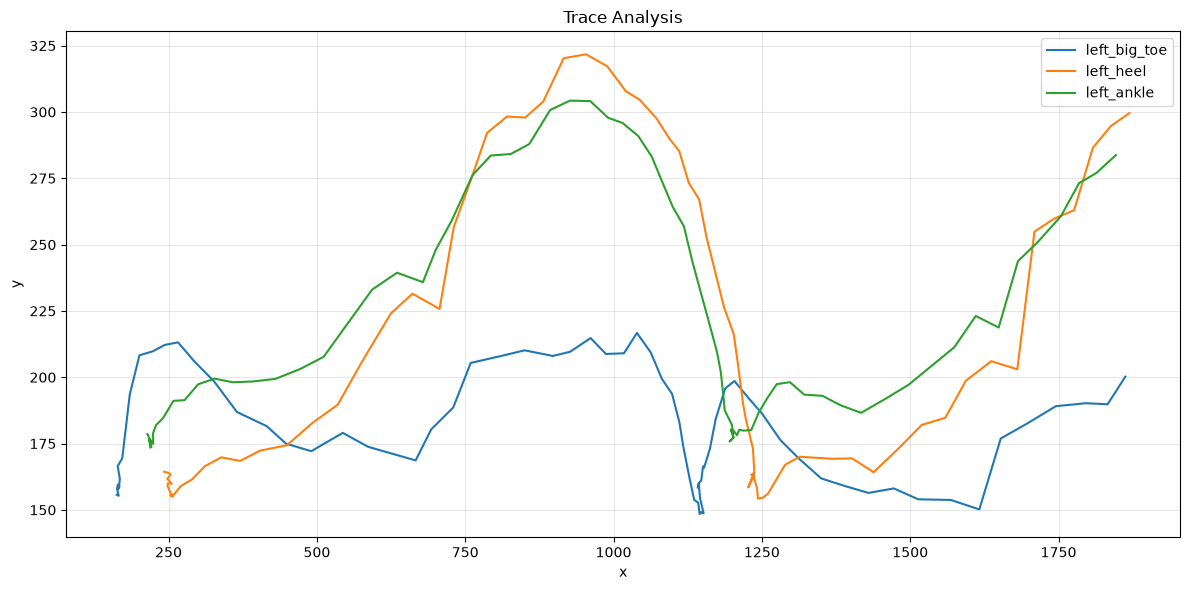

In [425]:
visualize_xy(df[["left_heel_x", "left_heel_y", "left_big_toe_x", "left_big_toe_y", "left_ankle_x", "left_ankle_y"]], 1080)

In [426]:
#    13: "left_knee",
#    14: "right_knee",

In [427]:
lkv = vel_acc_df["left_knee_vel"].to_frame()
lka = vel_acc_df["left_knee_acc"].to_frame()


In [428]:
fps = 25

In [429]:
lkv['time_s'] = (vel_acc_df.index.to_numpy() - 2) / fps
lka['time_s'] = (vel_acc_df.index.to_numpy() - 2) / fps

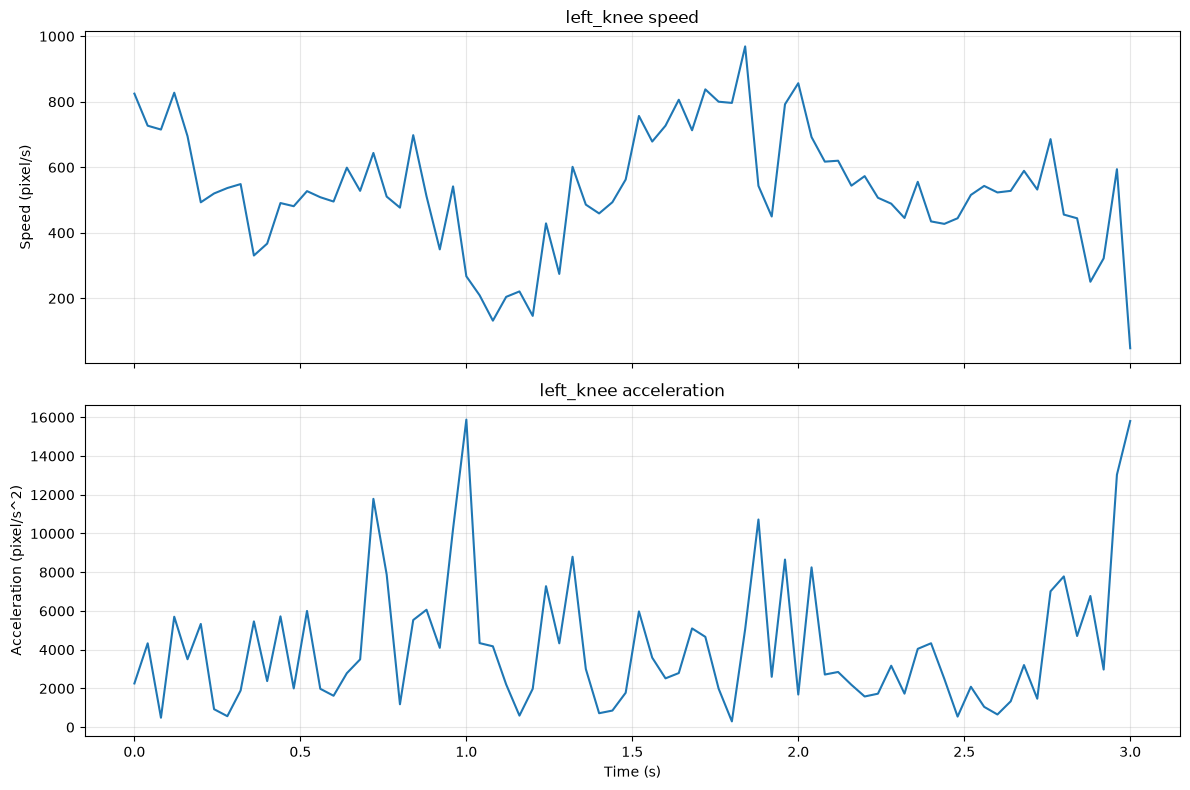

In [430]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 8),
    sharex=True,
)

axes[0].plot(
    lkv["time_s"],
    lkv["left_knee_vel"],
    color="tab:blue",
    linewidth=1.5,
)

axes[0].set_title("left_knee speed")
axes[0].set_ylabel("Speed (pixel/s)")
axes[0].grid(alpha=0.3)

axes[1].plot(
    lka["time_s"],
    lka["left_knee_acc"],
    color="tab:blue",
    linewidth=1.5,
)

axes[1].set_title("left_knee acceleration")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Acceleration (pixel/s^2)")
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

In [ ]:
# def knee_flexion_angle(hip, knee, ankle) -> float:

#     thigh = (np.asarray(hip, dtype=float) - np.asarray(knee, dtype=float)).T

#     shank = (np.asarray(ankle, dtype=float) - np.asarray(knee, dtype=float)).T

#     denominator = np.linalg.norm(thigh, axis=1) * np.linalg.norm(shank, axis=1)

#     # if denominator == 0 or not np.isfinite(denominator):
#     #     return np.nan
#     cosine = np.clip(np.sum((thigh * shank), axis=1) / denominator, -1.0, 1.0)

#     joint_angle = np.clip(np.degrees(np.arccos(cosine)), 0, 180)

#     return 180.0 - joint_angle

In [460]:
def knee_flexion_angle(
    hip,
    knee,
    ankle,
    orientation: float = 1.0,
) -> np.ndarray:
    """
    무릎 굴곡 각도를 계산한다.

    반환값:
        정상 굴곡: 양수
        완전 신전: 0
        반대 방향 과신전: 음수

    orientation:
        촬영 방향 때문에 부호가 반대이면 -1.0을 전달한다.
    """
    thigh = (
        np.asarray(hip, dtype=float)
        - np.asarray(knee, dtype=float)
    ).T

    shank = (
        np.asarray(ankle, dtype=float)
        - np.asarray(knee, dtype=float)
    ).T

    thigh_norm = np.linalg.norm(thigh, axis=1)
    shank_norm = np.linalg.norm(shank, axis=1)

    valid = (
        np.isfinite(thigh_norm)
        & np.isfinite(shank_norm)
        & (thigh_norm > 1e-8)
        & (shank_norm > 1e-8)
    )

    result = np.full(len(thigh), np.nan, dtype=float)

    dot = np.sum(thigh[valid] * shank[valid], axis=1)

    cross = (
        thigh[valid, 0] * shank[valid, 1]
        - thigh[valid, 1] * shank[valid, 0]
    )

    # 무릎을 중심으로 한 두 벡터의 방향 포함 각도
    signed_joint_angle = np.degrees(
        np.arctan2(cross, dot)
    )

    direction = np.where(signed_joint_angle >= 0, 1.0, -1.0)

    result[valid] = (
        orientation
        * direction
        * (180.0 - np.abs(signed_joint_angle))
    )

    # 부동소수점으로 생기는 극소값 제거
    result[np.isclose(result, 0.0, atol=1e-8)] = 0.0

    return result

In [461]:
df["left_hip_y"].shape

(78,)

In [462]:
help(np.arctan2)

Help on ufunc in module numpy:

arctan2 = <ufunc 'arctan2'>
    arctan2(x1, x2, /, out=None, *, where=True, casting='same_kind', order='K', dtype=None, subok=True[, signature])

    Element-wise arc tangent of ``x1/x2`` choosing the quadrant correctly.

    The quadrant (i.e., branch) is chosen so that ``arctan2(x1, x2)`` is
    the signed angle in radians between the ray ending at the origin and
    passing through the point (1,0), and the ray ending at the origin and
    passing through the point (`x2`, `x1`).  (Note the role reversal: the
    "`y`-coordinate" is the first function parameter, the "`x`-coordinate"
    is the second.)  By IEEE convention, this function is defined for
    `x2` = +/-0 and for either or both of `x1` and `x2` = +/-inf (see
    Notes for specific values).

    This function is not defined for complex-valued arguments; for the
    so-called argument of complex values, use `angle`.

    Parameters
    ----------
    x1 : array_like, real-valued
        `y`-co

In [493]:
df.columns

Index(['bbox_left', 'bbox_up', 'bbox_right', 'bbox_down', 'nose_x', 'nose_y',
       'left_eye_x', 'left_eye_y', 'right_eye_x', 'right_eye_y', 'left_ear_x',
       'left_ear_y', 'right_ear_x', 'right_ear_y', 'left_shoulder_x',
       'left_shoulder_y', 'right_shoulder_x', 'right_shoulder_y',
       'left_elbow_x', 'left_elbow_y', 'right_elbow_x', 'right_elbow_y',
       'left_wrist_x', 'left_wrist_y', 'right_wrist_x', 'right_wrist_y',
       'left_hip_x', 'left_hip_y', 'right_hip_x', 'right_hip_y', 'left_knee_x',
       'left_knee_y', 'right_knee_x', 'right_knee_y', 'left_ankle_x',
       'left_ankle_y', 'right_ankle_x', 'right_ankle_y', 'head_x', 'head_y',
       'neck_x', 'neck_y', 'hip_center_x', 'hip_center_y', 'left_big_toe_x',
       'left_big_toe_y', 'right_big_toe_x', 'right_big_toe_y',
       'left_small_toe_x', 'left_small_toe_y', 'right_small_toe_x',
       'right_small_toe_y', 'left_heel_x', 'left_heel_y', 'right_heel_x',
       'right_heel_y', 'right_instep_x', 'right_inst

In [500]:
(df["nose_x"] - df["neck_x"])[0]

np.float64(-49.674709743923586)

In [463]:
left_knee_angle = knee_flexion_angle(
    [df["left_hip_x"], df["left_hip_y"]],
    [df["left_knee_x"], df["left_knee_y"]],
    [df["left_ankle_x"], df["left_ankle_y"]]
)

In [503]:
1 == True

True

In [464]:
발착지예상프레임 = left_knee_angle.argmin() - 1

In [465]:
발착지예상프레임

np.int64(63)

In [466]:
df["left_heel_y"]

0     780.416360
1     785.322319
2     793.531699
3     817.037994
4     820.215081
         ...    
73    920.149070
74    918.262498
75    916.670109
76    915.996119
77    915.615939
Name: left_heel_y, Length: 78, dtype: float64

In [467]:
TD = df["left_heel_y"].argmax()

In [468]:
TD

np.int64(21)

In [469]:
left_knee_angle

array([77.72929489, 80.5618128 , 85.19026401, 83.6951592 , 80.79041587,
       77.89051414, 69.79334041, 62.64663957, 52.17361739, 41.6437186 ,
       36.13537507, 23.68261494, 10.2683058 ,  5.89673294,  4.34534741,
        0.62689246, -0.7801785 , -2.55487024,  1.7518129 ,  5.51611373,
        6.82111195,  8.21544091, 13.83651323, 24.77597138, 29.4771678 ,
       33.84981294, 40.92249119, 39.66917448, 35.44521129, 34.35119488,
       30.35152025, 23.33638345, 18.82080018, 20.58476226, 15.8283064 ,
       18.78132133, 20.16429773, 22.34509636, 25.42779712, 25.08783727,
       33.1245046 , 40.97710718, 51.05820203, 58.58021641, 67.1372314 ,
       76.90406278, 83.58558345, 88.44555786, 92.45431408, 93.45230874,
       93.18202748, 92.15296134, 88.35184602, 82.18056557, 75.85902992,
       70.16621633, 58.46508796, 46.8559657 , 36.96231568, 28.5090734 ,
       18.60912542, 11.47467566,  3.91944133, -1.92933437, -5.82778335,
       -5.73540996, -4.92525261, -3.55341912, -0.09354405,  9.25

In [470]:
left_knee_angle[12]

np.float64(10.268305798010175)

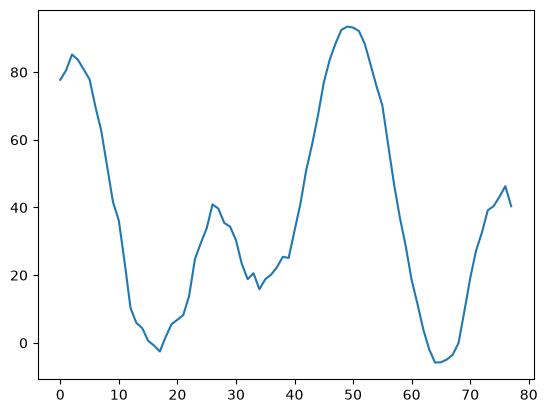

In [471]:
plt.plot(left_knee_angle)

In [472]:
y = np.asarray(left_knee_angle, dtype=float)
x = np.arange(len(y))

In [473]:
y_smooth = savgol_filter(
    y,
    window_length=5,
    polyorder=2
)

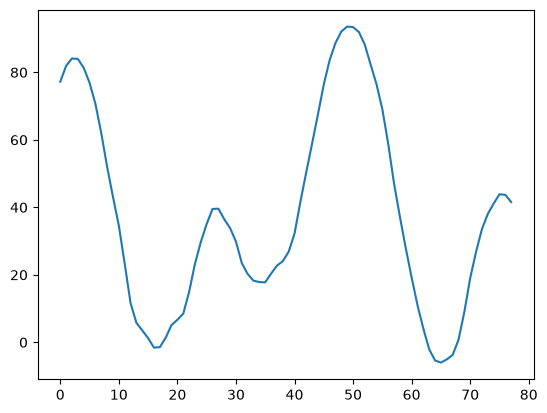

In [474]:
plt.plot(y_smooth)

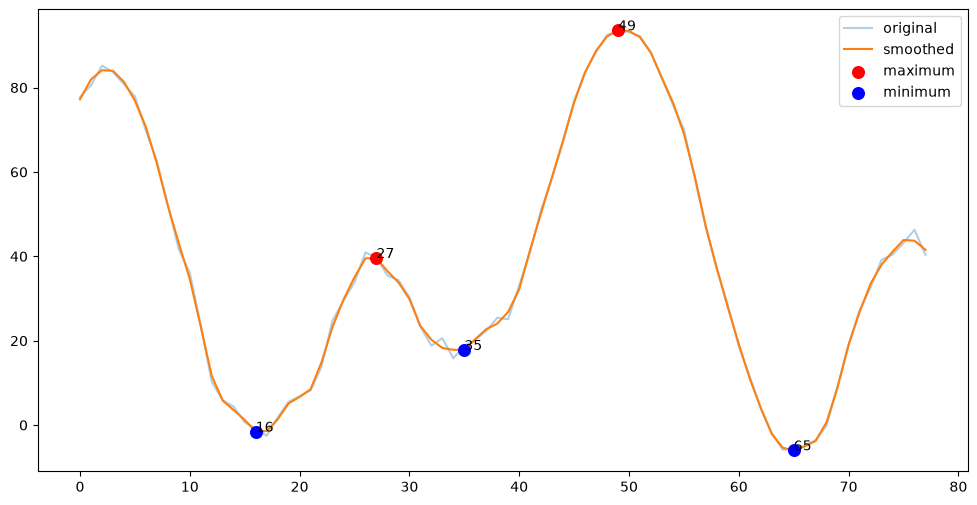

최댓값 프레임: [27 49]
최솟값 프레임: [16 35 65]


In [535]:
# 데이터 범위에 비례해 prominence 설정
signal_range = np.percentile(y_smooth, 95) - np.percentile(y_smooth, 5)
prominence = signal_range * 0.10    # 곱해지는 숫자가 클수록 큰 봉우리만 검출

# 최댓값
max_indices, max_properties = find_peaks(
    y_smooth,
    prominence=prominence,
    distance=10,
)

# 최솟값: 신호에 -를 붙여서 봉우리로 변환
min_indices, min_properties = find_peaks(
    -y_smooth,
    prominence=prominence,
    distance=10,
)

plt.figure(figsize=(12, 6))
plt.plot(x, y, alpha=0.35, label="original")
plt.plot(x, y_smooth, label="smoothed")

plt.scatter(
    max_indices,
    y_smooth[max_indices],
    color="red",
    s=70,
    label="maximum",
    zorder=3,
)

plt.scatter(
    min_indices,
    y_smooth[min_indices],
    color="blue",
    s=70,
    label="minimum",
    zorder=3,
)

for i in max_indices:
    plt.annotate(str(i), (i, y_smooth[i]))

for i in min_indices:
    plt.annotate(str(i), (i, y_smooth[i]))

plt.legend()
plt.show()

print("최댓값 프레임:", max_indices)
print("최솟값 프레임:", min_indices)

In [536]:
_max = {
    "frame": max_indices,
    "class": np.ones_like(max_indices)
}
_min = {
    "frame": min_indices,
    "class": np.zeros_like(min_indices)
}
extremum = pd.concat([pd.DataFrame(_max), pd.DataFrame(_min)]).sort_values('frame')


In [537]:
extremum

,frame,class
0,16,0
0,27,1
1,35,0
1,49,1
2,65,0


In [538]:
for i in range(1, len(extremum)):
    previous = extremum["class"].iloc[i - 1]
    current = extremum["class"].iloc[i]

    assert {previous, current} == {0, 1}, (
        f"예외: {i-1}, {i}행의 값이 {previous}, {current}입니다."
    )


In [539]:
res = []
for i in range(len(extremum) // 4 + 1):
    res.append(extremum['frame'].iloc[4 * i : 4 * i + 5].to_list())

In [540]:
res

[[16, 27, 35, 49, 65], [65]]